In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf
import inference_utils as iu

torch threads 1
Running on device cpu
torch threads 1


In [2]:
import torch
import pyro

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
# import pickle
import jsonpickle as pickle
import json
import gc
import numpy as np

from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

In [3]:
results_folder = "results"
inference_folder = os.path.join(results_folder, "inference")

model_comp_folder = os.path.join(results_folder, "model_comparison")

mask_file_name = "mask.txt"
processed_data_folder = os.path.join("processed_data")
mask_file = os.path.join(processed_data_folder, mask_file_name)

processed_data_folder = os.path.join("processed_data")

statistics_folder = os.path.join(results_folder, "statistics")

scores_file_name = "scores.csv"
scores_file = os.path.join(statistics_folder, scores_file_name)

agent_data_fname = "data_formatted_for_agent.pkl"
agent_data_file = os.path.join(processed_data_folder, agent_data_fname)

non_fit_fname = "non_fit_file.txt"
non_fit_file = os.path.join(model_comp_folder, non_fit_fname)

In [4]:
trials =  272#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
p_valid = 0.01

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid}

In [5]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

In [6]:
def convert_data_for_agent(data):

    data_obs = torch.stack([torch.from_numpy(d["observations"]) for d in data], dim=-1)
    data_rew = torch.stack([torch.from_numpy(d["rewards"]) for d in data], dim=-1)
    data_act = torch.stack([torch.from_numpy(d["actions"]) for d in data], dim=-1)
    data_val = torch.cat([torch.from_numpy(d["valid"]) for d in data], dim=-1)
    data_ind = torch.stack([torch.from_numpy(d["subject"]) for d in data], dim=-1)

    structured_data = {"subject": data_ind, "observations": data_obs, "rewards": data_rew, "actions": data_act, "valid": data_val}

    return structured_data

In [7]:
with open(agent_data_file, 'r') as infile:
    loaded = json.load(infile)
full_data = pickle.decode(loaded)

n_agents = len(full_data)
print("n subjects", n_agents)

data = convert_data_for_agent(full_data)

print(data)

exp_mask = data["valid"]

n subjects 24
{'subject': tensor([[ 0,  1,  2,  ..., 21, 22, 23],
        [ 0,  1,  2,  ..., 21, 22, 23],
        [ 0,  1,  2,  ..., 21, 22, 23],
        ...,
        [ 0,  1,  2,  ..., 21, 22, 23],
        [ 0,  1,  2,  ..., 21, 22, 23],
        [ 0,  1,  2,  ..., 21, 22, 23]]), 'observations': tensor([[[ 0,  0,  0,  ...,  0,  0,  0],
         [-1,  1,  1,  ...,  1,  1,  1],
         [-3,  3,  3,  ...,  5,  5,  3]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  2,  2,  ...,  1,  2,  2],
         [ 3,  6,  6,  ...,  5,  6,  4]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 1,  2,  1,  ...,  2,  2,  1],
         [ 3,  4,  5,  ...,  6,  6,  3]],

        ...,

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 0,  1,  0,  ...,  0,  0,  0],
         [ 0,  5,  0,  ...,  0,  0,  0]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 0,  1,  0,  ...,  0,  0,  0],
         [ 0,  3,  0,  ...,  0,  0,  0]],

        [[ 0,  0,  0,  ...,  0,  0,  0],
         [ 0,  1,  0,  

In [8]:
def load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names, use_h=False):    

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=False, 
                                                    use_h=use_h)

    print('analyzing '+str(n_agents)+' data sets')

    resample = False

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_sample_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
    else:
        mean_df, sample_df, locs_sample_df = iu.load_samples(base_dir, fname_str) 

    return mean_df, sample_df, locs_sample_df

In [9]:
# def load_MFMB_results(use_orig, learn_prior, use_p, restrict_alpha, max_dt, base_dir, global_experiment_parameters, valid, fname_base, num_steps, data, param_names):    

#     # set up agent
#     mfmb_agent = tu.set_up_mbmf_inference_agent(n_agents, learn_prior, use_orig, use_p, restrict_alpha, max_dt, 0, base_dir, global_experiment_parameters, valid, remove_old=False)

#     print('analyzing '+str(n_agents)+' data sets')

#     resample = False

#     # set up inference
#     inferrer = inf.GeneralGroupInference(mfmb_agent, data)

#     fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

#     inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

#     inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

#     if resample:
#         mean_df, sample_df, locs_sample_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir) 
#     else:
#         mean_df, sample_df, locs_sample_df = iu.load_samples(base_dir, fname_str) 

#     return mean_df, sample_df, locs_sample_df

In [10]:
def calculate_log_likelihood_mean_param(data, agent, locs_df, npars, trials, T):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # this is the likelihood of the average parameter
    # answer: multiply the log by 0

    n_agents = data["actions"].shape[-1]

    log_like = torch.zeros(n_agents)
    
    # print("locs df 0", locs_df["locs"+str(0)].shape)
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    # print("resulting locs", locs.shape)
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))

                log_like += torch.log(masked_probs)*data["valid"][tau].long()

    return log_like
    

In [11]:
def calculate_log_likelihood_mean_param_per_choice(data, agent, locs_df, npars, trials, T):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # this is the likelihood of the average parameter
    # answer: multiply the log by 0

    n_agents = data["actions"].shape[-1]

    log_like = []
    
    # print("locs df 0", locs_df["locs"+str(0)].shape)
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    # print("resulting locs", locs.shape)
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                test = probs > 1
                if test.sum()>0:
                    print(probs)
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]
                test = likes > 1
                if test.sum()>0:
                    print(likes)

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))

                test = masked_probs > 1
                if test.sum()>0:
                    print("masked", masked_probs)

                log_like.append(torch.log(masked_probs))#*data["valid"][tau].long())

                test = torch.exp(log_like[-1]) > 1
                if test.sum()>0:
                    print("log like", torch.exp(log_like[-1]))


    log_like = torch.stack(log_like, dim=0)

    test = torch.exp(log_like) > 1
    if test.sum()>0:
        print("total")

    return log_like
    

In [12]:
def calculate_lppd(data, agent, locs_df, npars, trials, T, max_samples=-1):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # Eqs (4,5) from here:
    # http://www.stat.columbia.edu/~gelman/research/published/waic_understand3.pdf
    # this is the average likelihood
    
    n_agents = data["actions"].shape[-1]
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(torch.tensor(locs_df[locs_df["subject"]==i]["locs"+str(k)].values[:max_samples]).float())
        locs_list.append(torch.stack(locs_subs, dim=-1))

    locs = torch.stack(locs_list, dim=-1)
    print("lppd locs", locs.shape)
    
    assert(locs.shape[1]==n_agents)

    #locs = torch.stack([torch.tensor(locs_df["locs"+str(i)]) for i in range(npars)], dim=-1).float()[:max_samples]

    #print("locs", locs.shape)

    n_samples = locs.shape[0]

    likelihoods = []

    agent.reset(locs)

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                #print("probs", probs.shape)
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))
                #print("masked probs", masked_probs.shape)

                likelihoods.append(masked_probs)

                #print(tau,t)

    mean_like = torch.stack(likelihoods, dim=0)
    # print("mean like stacked", mean_like.shape)
    # print(mean_like)

    mean_like = mean_like.sum(dim=-2) / n_samples
    # print("mean like summed", mean_like.shape)
    # print(mean_like)

    mean_log_like = torch.log(mean_like).sum(dim=0)

    #print(mean_log_like)
    # print("mean log like", mean_log_like.shape)
    # print(mean_log_like)

    return mean_log_like
    

In [13]:
def predictive_accuracy_mean_param(data, agent, locs_df, npars, trials, T):

    n_agents = data["actions"].shape[-1]

    predicted_accuracy = torch.zeros(n_agents)
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    num_valid_responses = torch.zeros(data["actions"].shape[-1])

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:
                #print(tau,t)

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]#*data["valid"][tau].long()
                #print(curr_response)

                predicted_response = torch.argmax(probs, dim=0)[0]

                #print(probs)

                #print(predicted_response)

                correct_response_predicted = (curr_response == predicted_response).int()

                #print(correct_response_predicted)

                predicted_accuracy += correct_response_predicted

                num_valid_responses += data["valid"][tau]

                #print(num_valid_responses)


    corrected_predicted_accuracy = predicted_accuracy / num_valid_responses

    return corrected_predicted_accuracy

In [14]:
def calculate_avg_likelihood_mean_param(data, agent, locs_df, npars, trials, T):

    # question: what do with nan trials? If I ignore them, they will decrease the likelihood and make subject seem to fit better. If I make them uniform, itll decrease by a lot?
    # this is the likelihood of the average parameter
    
    n_agents = data["actions"].shape[-1]

    like = torch.zeros(n_agents)
    log_like = torch.zeros(n_agents)
    
    locs_list = []
    for k in range(npars):
        locs_subs = []
        for i in range(n_agents):
            locs_subs.append(locs_df[locs_df["subject"]==i]["locs"+str(k)].mean())
        locs_list.append(torch.tensor(locs_subs).float())

    locs = torch.stack(locs_list, dim=-1)
    
    assert(locs.shape[0]==n_agents)

    agent.reset(locs)

    num_valid_responses = torch.zeros(data["actions"].shape[-1])

    for tau in pyro.markov(range(trials)):
        for t in range(T):

            if t==0:
                prev_response = None
                context = None
            else:
                prev_response = data["actions"][tau, t-1]
                context = None

            observation = data["observations"][tau, t]

            reward = data["rewards"][tau, t]

            agent.update_beliefs(tau, t, observation, reward, prev_response, context)

            if t < T-1:

                probs = agent.perception.posterior_actions[-1]
                if torch.any(torch.isnan(probs)):
                    print(probs)
                    #print(param_dict)
                    print(tau,t)

                curr_response = data["actions"][tau, t]*data["valid"][tau].long()

                one_hot_responses = torch.nn.functional.one_hot(curr_response, num_classes=2).permute((1,0))[:,None,:].float()

                likes = (probs * one_hot_responses).sum(dim=0)[0]

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.0]))

                like += masked_probs*data["valid"][tau]

                masked_probs = torch.where(data["valid"][tau], likes, torch.tensor([0.5]))

                log_like += torch.log(masked_probs)*data["valid"][tau]

                num_valid_responses += data["valid"][tau]

    avg_like = like / num_valid_responses
    avg_log_like = log_like / num_valid_responses
    avg_like_from_log = torch.exp(avg_log_like)

    return avg_like, avg_like_from_log
    

### make plot helper function

In [15]:
def plot_correlations(plot_df, x_vars_of_interest, y_vars_of_interest):

    if set(x_vars_of_interest) == set(y_vars_of_interest):
        square = True
        vars_of_interest = x_vars_of_interest
    else:
        square = False
        vars_of_interest = x_vars_of_interest+y_vars_of_interest
    rho = plot_df[vars_of_interest].corr()
    pval = plot_df[vars_of_interest].corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
    reject, pval_corrected, alphaS, alphaB = multipletests(pval, method='bonferroni')

    if square:
        mask = np.triu(np.ones_like(rho, dtype=bool), k=1)
    else:
        mask = np.zeros_like(rho.loc[x_vars_of_interest,y_vars_of_interest], dtype=bool)

    plt.figure()

    alpha_plot = np.where(pval.loc[x_vars_of_interest,y_vars_of_interest]<0.05, 1, 0.1)
    # sns.set(font_scale=1.2)
    g = sns.heatmap(rho.loc[x_vars_of_interest,y_vars_of_interest], annot=rho.loc[x_vars_of_interest,y_vars_of_interest], fmt='.2f', cmap='Spectral_r', alpha=alpha_plot, 
                # palettes: crest, icefire, vlag, Greys, RdGy, RdBu, etc etc, and add _r for reversed
                vmin=-1, vmax=1, mask=mask, annot_kws={"size": 12})#, ax=ax)
    g.set_xticklabels(g.get_xmajorticklabels(), fontsize = 12)
    g.set_yticklabels(g.get_ymajorticklabels(), fontsize = 12)
    cbar = g.collections[0].colorbar
    cbar.ax.tick_params(labelsize=12)

    plt.show()

### Load BCC2 planning results, and plot correlations between inferred parameters

BCC_2pars_plan_NO_context
BCC_2pars_plan_NO_context_inference_
2
analyzing 24 data sets
2


/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/perception.py:136: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  self.big_trans_matrix = ar.stack([ar.stack([generative_model_states[:,:,policies[pi,t]] for pi in range(self.npi)]) for t in range(self.T-1)]).T.to(device)
/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://g

<Figure size 640x480 with 0 Axes>

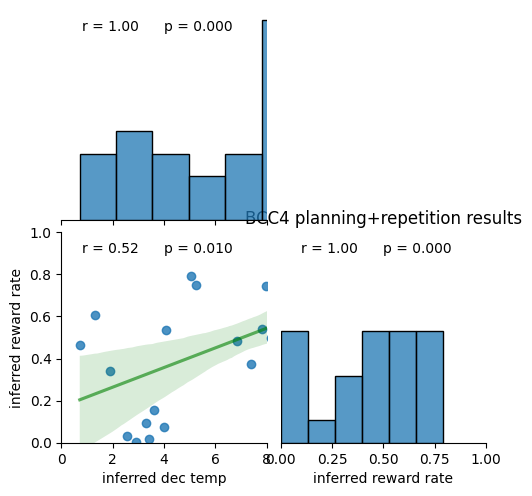

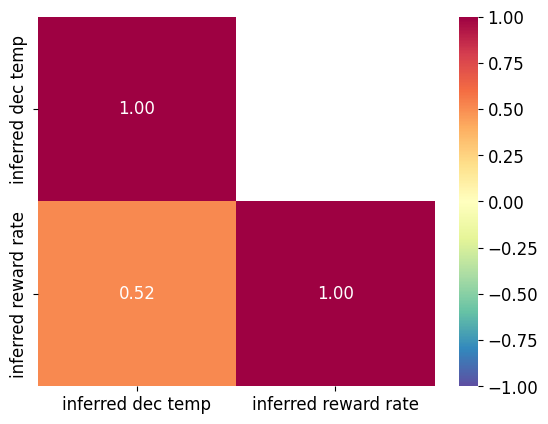

In [16]:
# BCC2 planning analysis

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC2_param_names = param_names.copy()
BCC2_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC2_mean_df, BCC2_sample_df, BCC2_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC2_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC2_params = torch.stack([torch.tensor(BCC2_mean_df["inferred "+name]) for name in BCC2_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC2_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC2_mean_df, vars_of_interest, vars_of_interest)


### Load BCC4 planning+repetition results, and plot correlations between inferred parameters

BCC_4pars_plan_habit_weight_NO_context
BCC_4pars_plan_habit_weight_NO_context_inference_
4
analyzing 24 data sets
4


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

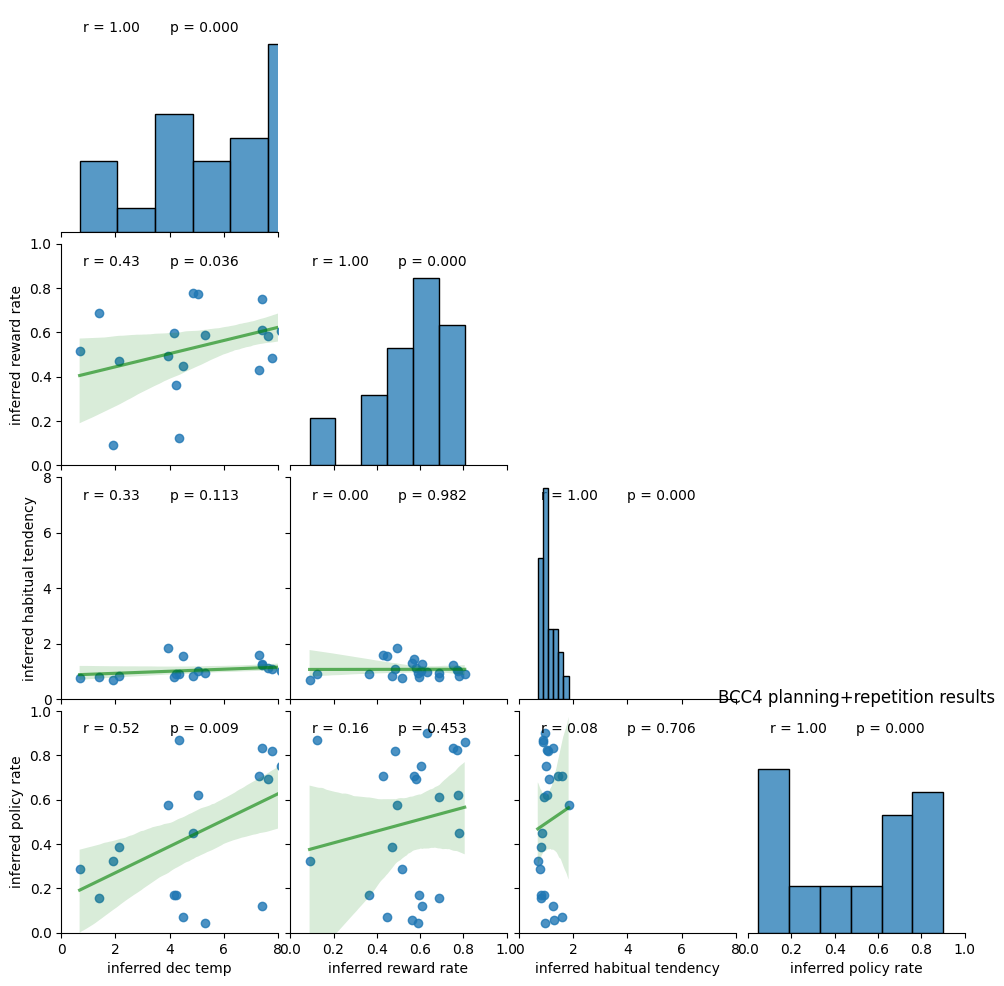

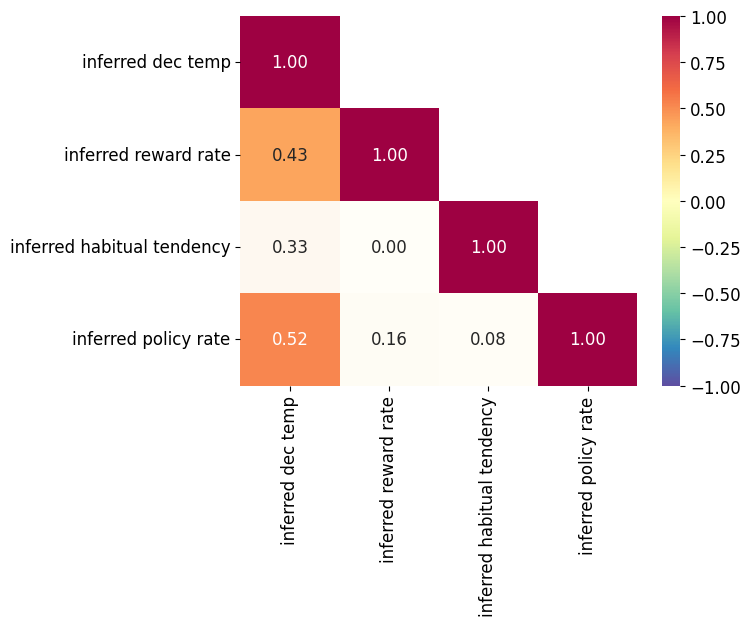

In [17]:
# BCC4 planning repetition analysis

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC4_p_r_param_names = param_names.copy()
BCC4_p_r_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC4_p_r_mean_df, BCC4_p_r_sample_df, BCC4_p_r_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC4_p_r_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC4_p_r_params = torch.stack([torch.tensor(BCC4_p_r_mean_df["inferred "+name]) for name in BCC4_p_r_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_r_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC4_p_r_mean_df, vars_of_interest, vars_of_interest)


### Load BCC4 planning+cached results, and plot correlations between inferred parameters

BCC_4pars_plan_cached_NO_context
BCC_4pars_plan_cached_NO_context_inference_
4
analyzing 24 data sets
4


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

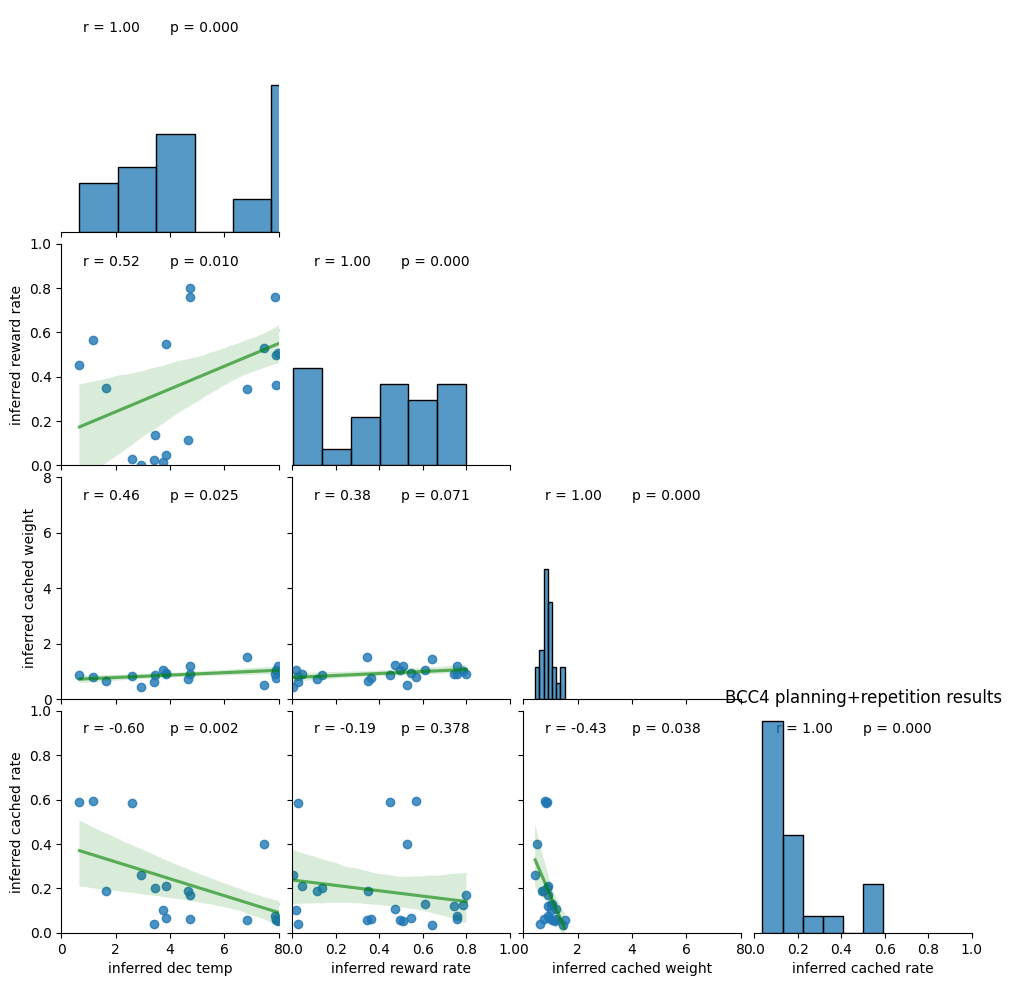

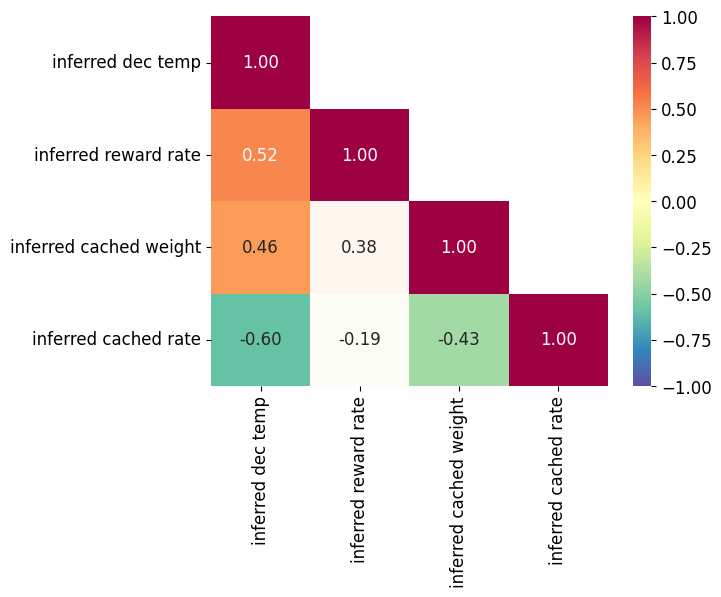

In [18]:
# BCC4 planning cached analysis

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC4_p_c_param_names = param_names.copy()
BCC4_p_c_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC4_p_c_mean_df, BCC4_p_c_sample_df, BCC4_p_c_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC4_p_c_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC4_p_c_params = torch.stack([torch.tensor(BCC4_p_c_mean_df["inferred "+name]) for name in BCC4_p_c_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC4_p_c_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()


plot_correlations(BCC4_p_c_mean_df, vars_of_interest, vars_of_interest)

### Load BCC6results, and plot correlations between inferred parameters

BCC_6pars_plan_habit_weight_cached_NO_context
BCC_6pars_plan_habit_weight_cached_NO_context_inference_
6
analyzing 24 data sets
6


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/pyro/params/param_store.py:334: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(inp

<Figure size 640x480 with 0 Axes>

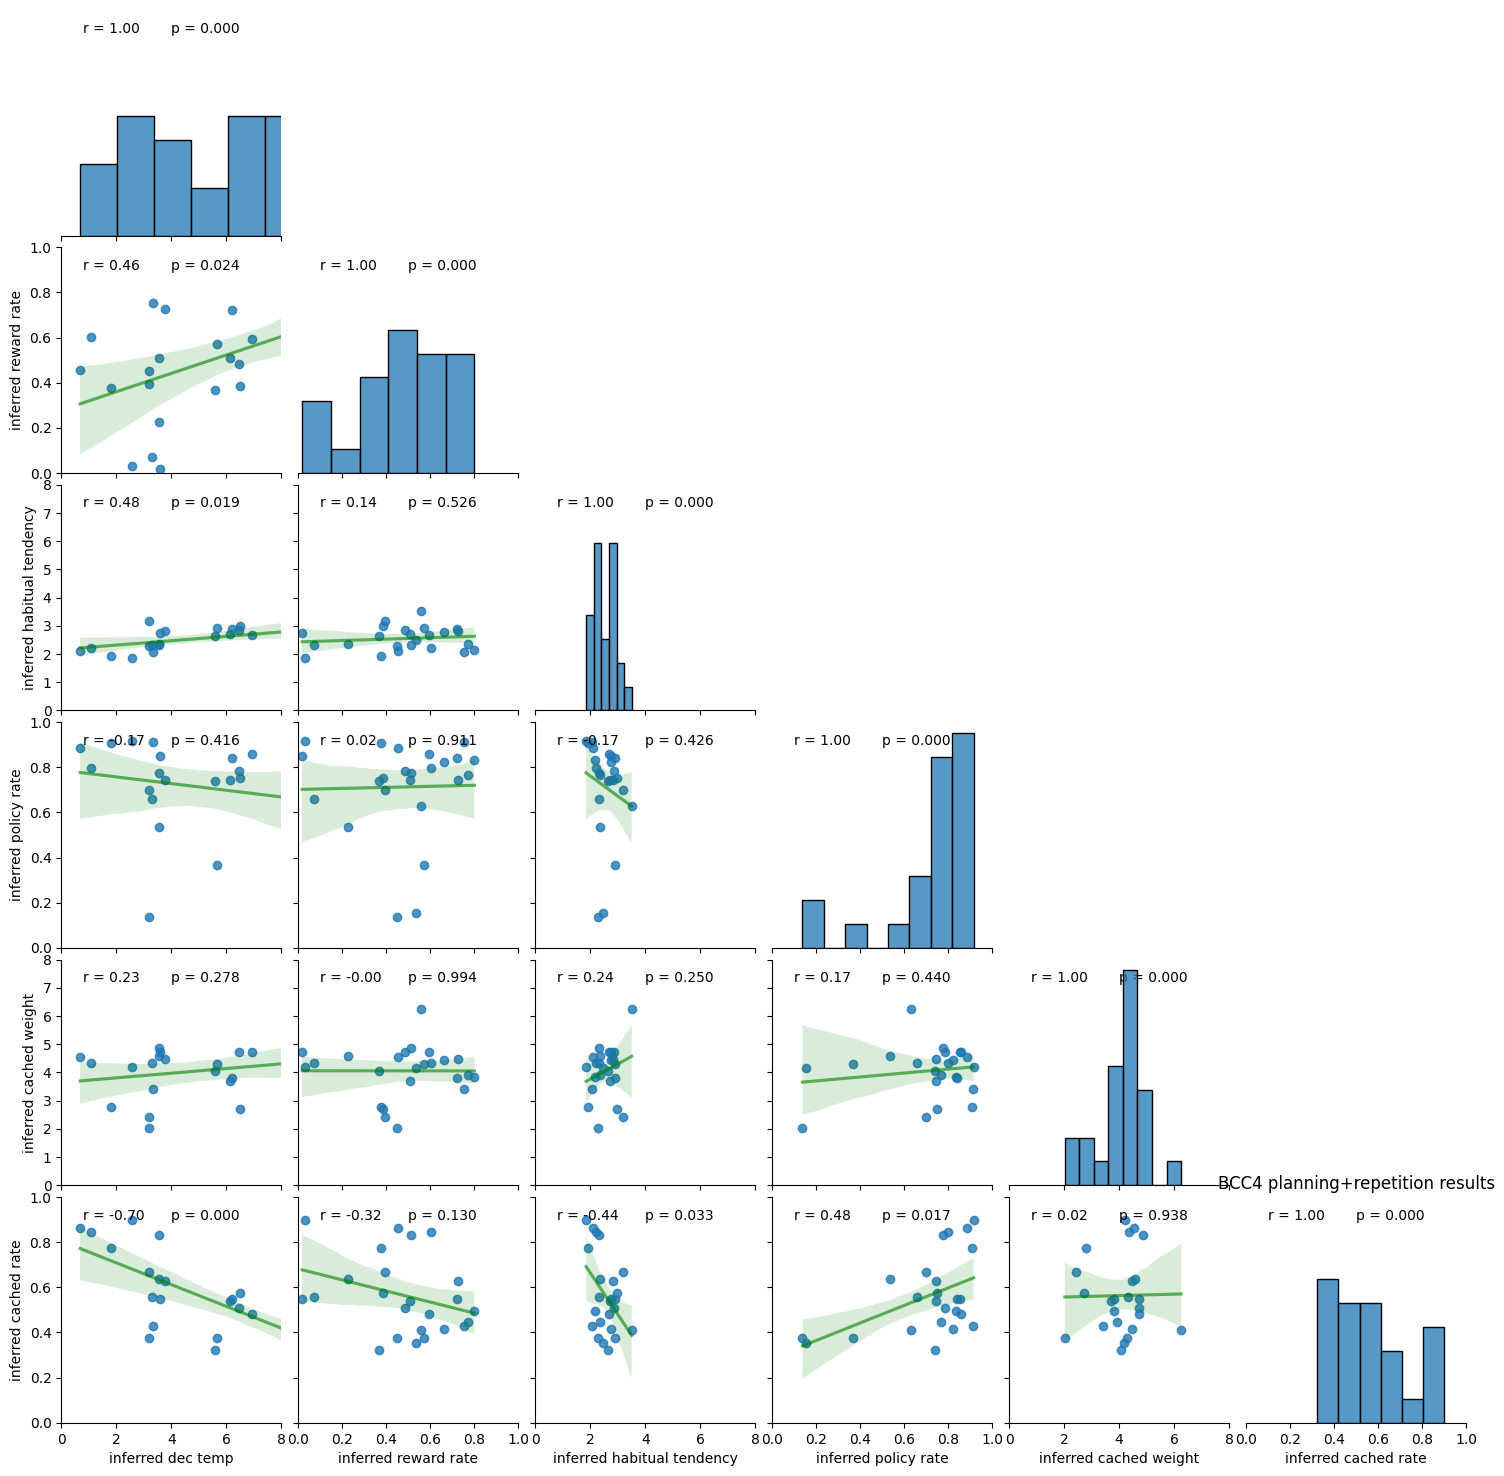

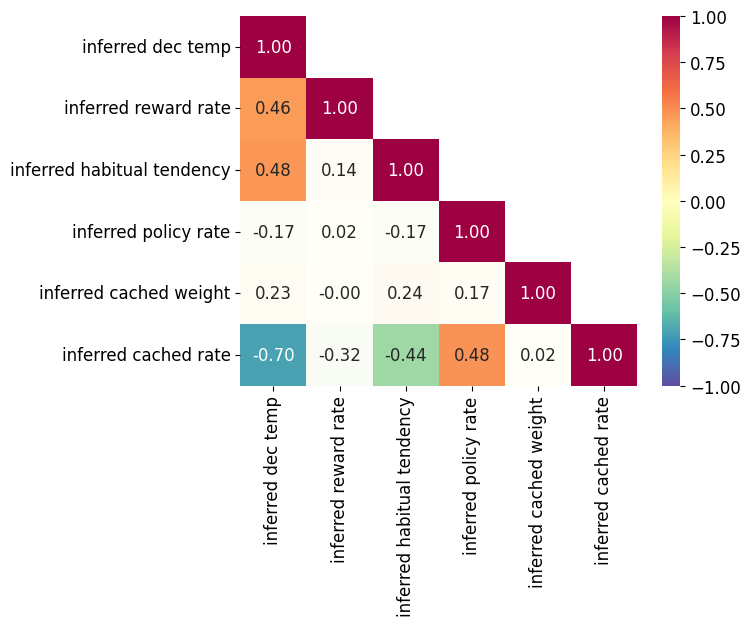

In [19]:
# BCC6 analysis

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_plan"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_habit"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

BCC6_param_names = param_names.copy()
BCC6_param_ranges = param_ranges.copy()

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str+"_NO_context"
print(agent_type)

# prepare for saving results
# make base filename and folder string
fname_base = agent_type+"_inference_"
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(inference_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(inference_folder):
    os.mkdir(base_dir)

num_steps = 600

BCC6_mean_df, BCC6_sample_df, BCC6_locs_df = load_BCC_results(learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, exp_mask, fname_base, num_steps, data, param_names, use_h=False)

BCC6_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, global_experiment_parameters, data["valid"], remove_old=False, use_h=use_h)

BCC6_params = torch.stack([torch.tensor(BCC6_mean_df["inferred "+name]) for name in BCC6_param_names], dim=-1)

# param_plot_ranges = [[-0.25,1.25], [-0.25,1.25], [0,10]]

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=BCC6_mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.title("BCC4 planning+repetition results")
#plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

plot_correlations(BCC6_mean_df, vars_of_interest, vars_of_interest)

In [20]:
# calculate agent log likelihood using mean params

BCC2_log_like = -calculate_log_likelihood_mean_param(data, BCC2_agent, BCC2_locs_df, len(BCC2_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC2_lppd = -calculate_lppd(data, BCC2_agent, BCC2_locs_df, len(BCC2_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC2_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC2"]*n_agents})
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC2_lppd, "type": ["lppd"]*n_agents, "model": ["BCC2"]*n_agents})])

print("BCC2 log like", BCC2_log_like.mean())

print("BCC2 lppd", BCC2_log_like.mean())

gc.collect()

lppd locs torch.Size([50, 24, 2])
BCC2 log like tensor(249.0758)
BCC2 lppd tensor(249.0758)


46256

In [21]:
# calculate agent log likelihood using mean params

BCC4_p_r_log_like = -calculate_log_likelihood_mean_param(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_r_lppd = -calculate_lppd(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC4_p_r"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_r_lppd, "type": ["lppd"]*n_agents, "model": ["BCC4_p_r"]*n_agents})])

print("BCC4_p_r log like", BCC4_p_r_log_like.mean())

print("BCC4_p_r lppd", BCC4_p_r_log_like.mean())

gc.collect()

lppd locs torch.Size([50, 24, 4])
BCC4_p_r log like tensor(232.0698)
BCC4_p_r lppd tensor(232.0698)


1688

In [22]:
# calculate agent log likelihood using mean params

BCC4_p_c_log_like = -calculate_log_likelihood_mean_param(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_lppd = -calculate_lppd(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC4_p_c_lppd, "type": ["lppd"]*n_agents, "model": ["BCC4_p_c"]*n_agents})])

print("BCC4_p_c log like", BCC4_p_c_log_like.mean())

print("BCC4_p_c lppd", BCC4_p_c_log_like.mean())

gc.collect()

lppd locs torch.Size([50, 24, 4])
BCC4_p_c log like tensor(246.9296)
BCC4_p_c lppd tensor(246.9296)


1876

In [23]:
# calculate agent log likelihood using mean params

BCC6_log_like = -calculate_log_likelihood_mean_param(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_lppd = -calculate_lppd(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), 
                            global_experiment_parameters["trials"], global_experiment_parameters["T"], max_samples=50)

measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_log_like, "type": ["log likelihood"]*n_agents, "model": ["BCC6"]*n_agents})])
measures_df = pd.concat([measures_df, pd.DataFrame({"subject": list(range(n_agents)), "measure": BCC6_lppd, "type": ["lppd"]*n_agents, "model": ["BCC6"]*n_agents})])

print("BCC6 log like", BCC6_log_like.mean())

print("BCC6 lppd", BCC6_log_like.mean())

gc.collect()

lppd locs torch.Size([50, 24, 6])
BCC6 log like tensor(222.2162)
BCC6 lppd tensor(222.2162)


1031

In [24]:
print(measures_df)

    subject     measure            type model
0         0  234.986191  log likelihood  BCC2
1         1  277.624756  log likelihood  BCC2
2         2  236.015366  log likelihood  BCC2
3         3  234.873672  log likelihood  BCC2
4         4  248.273422  log likelihood  BCC2
..      ...         ...             ...   ...
19       19  313.189606            lppd  BCC6
20       20  278.517761            lppd  BCC6
21       21  349.249786            lppd  BCC6
22       22  361.202332            lppd  BCC6
23       23  285.270508            lppd  BCC6

[192 rows x 4 columns]


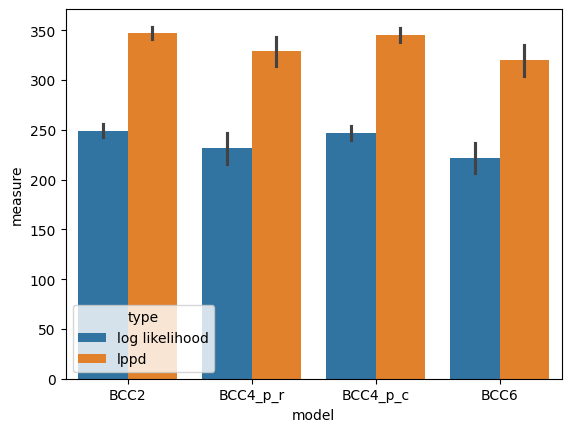

In [25]:
plt.figure()
sns.barplot(data=measures_df, x="model", y="measure", hue="type")
plt.savefig(os.path.join(model_comp_folder, "model_comparison.svg"))
plt.savefig(os.path.join(model_comp_folder, "model_comparison.png"))
plt.show()

### compare predictive accuracies as sanity check

In [26]:
BCC2_pred_acc = predictive_accuracy_mean_param(data, BCC2_agent, BCC2_locs_df, len(BCC2_param_names), 
                                               global_experiment_parameters["trials"], global_experiment_parameters["T"])
BCC2_avg_like, BCC2_avg_like_from_log = calculate_avg_likelihood_mean_param(data, BCC2_agent, BCC2_locs_df, len(BCC2_param_names), 
                                                    global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_r_pred_acc = predictive_accuracy_mean_param(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), 
                                               global_experiment_parameters["trials"], global_experiment_parameters["T"])
BCC4_p_r_avg_like, BCC4_p_r_avg_like_from_log = calculate_avg_likelihood_mean_param(data, BCC4_p_r_agent, BCC4_p_r_locs_df, len(BCC4_p_r_param_names), 
                                                    global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC4_p_c_pred_acc = predictive_accuracy_mean_param(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), 
                                               global_experiment_parameters["trials"], global_experiment_parameters["T"])
BCC4_p_c_avg_like, BCC4_p_c_avg_like_from_log = calculate_avg_likelihood_mean_param(data, BCC4_p_c_agent, BCC4_p_c_locs_df, len(BCC4_p_c_param_names), 
                                                    global_experiment_parameters["trials"], global_experiment_parameters["T"])

BCC6_pred_acc = predictive_accuracy_mean_param(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), 
                                               global_experiment_parameters["trials"], global_experiment_parameters["T"])
BCC6_avg_like, BCC6_avg_like_from_log = calculate_avg_likelihood_mean_param(data, BCC6_agent, BCC6_locs_df, len(BCC6_param_names), 
                                                    global_experiment_parameters["trials"], global_experiment_parameters["T"])

In [27]:
avg_measures_df = pd.DataFrame({"type": ["predictive accuracy"]*n_agents, "measure": BCC2_pred_acc, "model": ["BCC2"]*n_agents, "subject": list(range(n_agents))})
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["predictive accuracy"]*n_agents, "measure": BCC4_p_r_pred_acc, "model": ["BCC4_p_r"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["predictive accuracy"]*n_agents, "measure": BCC4_p_c_pred_acc, "model": ["BCC4_p_c"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["predictive accuracy"]*n_agents, "measure": BCC6_pred_acc, "model": ["BCC6"]*n_agents, "subject": list(range(n_agents))})])

In [28]:
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood"]*n_agents, "measure": BCC2_avg_like, "model": ["BCC2"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood"]*n_agents, "measure": BCC4_p_r_avg_like, "model": ["BCC4_p_r"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood"]*n_agents, "measure": BCC4_p_c_avg_like, "model": ["BCC4_p_c"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood"]*n_agents, "measure": BCC6_avg_like, "model": ["BCC6"]*n_agents, "subject": list(range(n_agents))})])

In [29]:
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood from log"]*n_agents, "measure": BCC2_avg_like_from_log, "model": ["BCC2"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood from log"]*n_agents, "measure": BCC4_p_r_avg_like_from_log, "model": ["BCC4_p_r"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood from log"]*n_agents, "measure": BCC4_p_c_avg_like_from_log, "model": ["BCC4_p_c"]*n_agents, "subject": list(range(n_agents))})])
avg_measures_df = pd.concat([avg_measures_df, pd.DataFrame({"type": ["average likelihood from log"]*n_agents, "measure": BCC6_avg_like_from_log, "model": ["BCC6"]*n_agents, "subject": list(range(n_agents))})])

In [30]:
avg_measures_df

,type,measure,model,subject
0,predictive accuracy,0.696517,BCC2,0
1,predictive accuracy,0.552239,BCC2,1
2,predictive accuracy,0.703980,BCC2,2
3,predictive accuracy,0.708955,BCC2,3
4,predictive accuracy,0.626866,BCC2,4
...,...,...,...,...
19,average likelihood from log,0.586312,BCC6,19
20,average likelihood from log,0.639644,BCC6,20
21,average likelihood from log,0.536016,BCC6,21
22,average likelihood from log,0.520074,BCC6,22


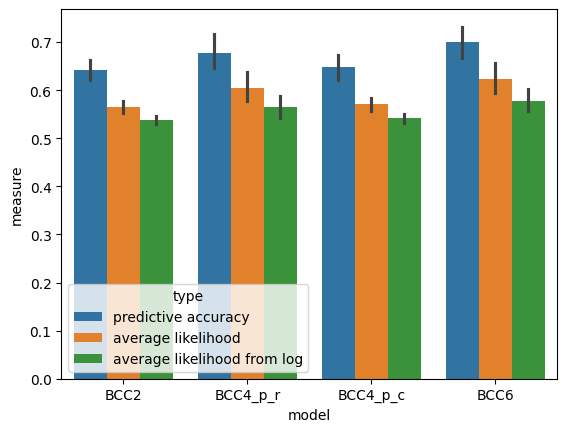

In [31]:
plt.figure()
sns.barplot(data=avg_measures_df, x="model", y="measure", hue="type")
plt.savefig(os.path.join(model_comp_folder, "pred_acc.svg"))
plt.savefig(os.path.join(model_comp_folder, "pred_acc.png"))
plt.show()

In [32]:
# plot_df = avg_measures_df[avg_measures_df["model"]=="MFMB4"]

# plt.figure()
# sns.histplot(data=plot_df, x="measure", hue="type")
# plt.show()

3 participants have random behavior under the BCC2 model (p>0.01)


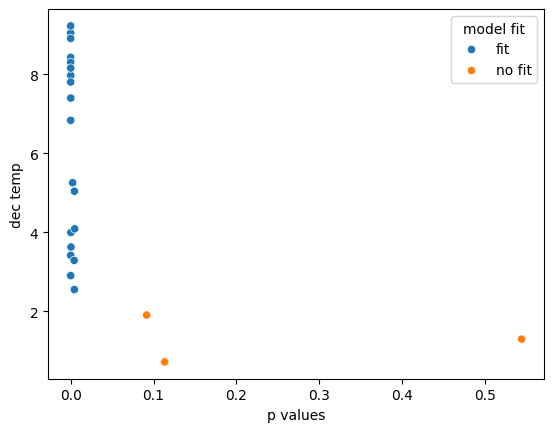

[1, 16, 17]


In [33]:
from scipy.stats import ttest_1samp

BCC2_log_like_per_choice = -calculate_log_likelihood_mean_param_per_choice(data, BCC2_agent, BCC2_locs_df, 
                                                     len(BCC2_param_names), global_experiment_parameters["trials"], 
                                                     global_experiment_parameters["T"])

ttest_results = []
BCC2_didnt_fit = []
p_values = []
didnt_fit_str = []

null_hypothesis = -torch.log(torch.tensor(0.5))
significance_level = 0.01

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC2_log_like_per_choice[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC2_didnt_fit.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

p_values = torch.tensor(p_values)

print(len(BCC2_didnt_fit), "participants have random behavior under the BCC2 model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC2_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC3_1_mean_df["inferred dec temp"])

print(BCC2_didnt_fit)


6 participants have random behavior under the BCC4_p_r model (p>0.01)


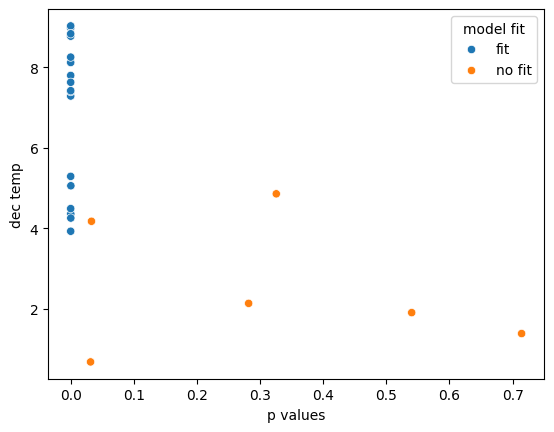

[1, 7, 16, 17, 21, 22]


In [34]:
from scipy.stats import ttest_1samp

BCC4_p_r_log_like_per_choice = -calculate_log_likelihood_mean_param_per_choice(data, BCC4_p_r_agent, BCC4_p_r_locs_df, 
                                                     len(BCC4_p_r_param_names), global_experiment_parameters["trials"], 
                                                     global_experiment_parameters["T"])

ttest_results = []
BCC4_p_r_didnt_fit = []
p_values = []
didnt_fit_str = []

# null_hypothesis = -torch.log(torch.tensor(0.5))
# significance_level = 0.01

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC4_p_r_log_like_per_choice[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC4_p_r_didnt_fit.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

p_values = torch.tensor(p_values)

print(len(BCC4_p_r_didnt_fit), "participants have random behavior under the BCC4_p_r model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC4_p_r_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC3_1_mean_df["inferred dec temp"])

print(BCC4_p_r_didnt_fit)


3 participants have random behavior under the BCC4_p_c model (p>0.01)


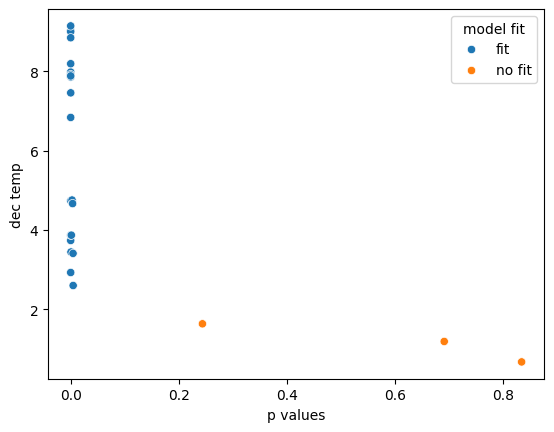

[1, 16, 17]


In [35]:
from scipy.stats import ttest_1samp

BCC4_p_c_log_like_per_choice = -calculate_log_likelihood_mean_param_per_choice(data, BCC4_p_c_agent, BCC4_p_c_locs_df, 
                                                     len(BCC4_p_c_param_names), global_experiment_parameters["trials"], 
                                                     global_experiment_parameters["T"])

ttest_results = []
BCC4_p_c_didnt_fit = []
p_values = []
didnt_fit_str = []

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC4_p_c_log_like_per_choice[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC4_p_c_didnt_fit.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

p_values = torch.tensor(p_values)

print(len(BCC4_p_c_didnt_fit), "participants have random behavior under the BCC4_p_c model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC4_p_c_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC3_1_mean_df["inferred dec temp"])

print(BCC4_p_c_didnt_fit)


4 participants have random behavior under the BCC6 model (p>0.01)


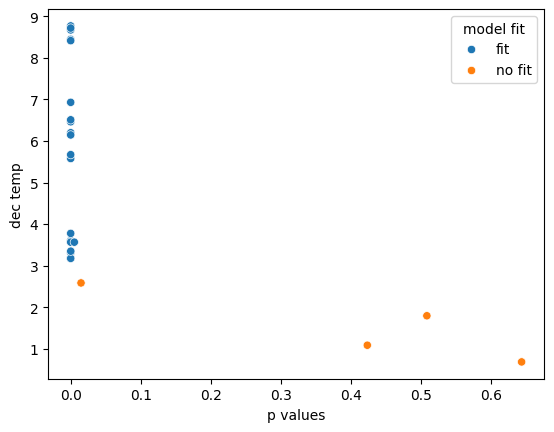

[1, 7, 16, 17]


In [36]:
from scipy.stats import ttest_1samp

BCC6_log_like_per_choice = -calculate_log_likelihood_mean_param_per_choice(data, BCC6_agent, BCC6_locs_df, 
                                                     len(BCC6_param_names), global_experiment_parameters["trials"], 
                                                     global_experiment_parameters["T"])

ttest_results = []
BCC6_didnt_fit = []
p_values = []
didnt_fit_str = []

for n in range(n_agents):
    ttest_results.append(ttest_1samp(BCC6_log_like_per_choice[:,n], null_hypothesis))
    p_values.append(ttest_results[-1].pvalue)
    #print(ttest_results[-1])
    if ttest_results[-1].pvalue > significance_level:
        #print(n)
        #print(ttest_results[-1])
        BCC6_didnt_fit.append(n)
        didnt_fit_str.append("no fit")
    else:
        didnt_fit_str.append("fit")

p_values = torch.tensor(p_values)

print(len(BCC6_didnt_fit), "participants have random behavior under the BCC6 model (p>"+str(significance_level)+")")

plot_df_corr_p_val_dec_temp = pd.DataFrame({"p values": p_values, "model fit": didnt_fit_str,
                                            "dec temp": BCC6_mean_df["inferred dec temp"],
                                            "subject": list(range(n_agents))})
plt.figure()
sns.scatterplot(data=plot_df_corr_p_val_dec_temp, x="p values", y="dec temp", hue="model fit")#, style="model fit", hue="subject")
plt.show()
#pearsonr(p_values, BCC3_1_mean_df["inferred dec temp"])

print(BCC6_didnt_fit)


In [38]:
# which participants dont fit in all models?

all_didnt_fit = list(set(BCC4_p_r_didnt_fit) & set(BCC4_p_r_didnt_fit) & set(BCC4_p_c_didnt_fit) & set(BCC6_didnt_fit))

# MFMB_didnt_fit = list(set(MFMB4_didnt_fit) & set(MFMB6_didnt_fit))

# all_didnt_fit = list(set(BCC_didnt_fit) & set(MFMB_didnt_fit))

print(len(all_didnt_fit), "didnt fit in all the models:")
print(all_didnt_fit)

with open(non_fit_file, "w") as f:
    json.dump(all_didnt_fit, f)

3 didnt fit in all the models:
[16, 1, 17]
